In [1]:
# Data loading and synchronization 
from ingestion.data_paths import DataStorageManager
from ingestion.ephys_sync import DataSyncManager
from ingestion.kilosort_data_import import KilosortData
from video.behavioral_events import BehavioralEventsData

animal_id = "rat631"
session_date = "20251216"
data_storage = DataStorageManager(animal_id, session_date, auto_load=True)
behavior_data = BehavioralEventsData(data_storage)
ks_data = KilosortData(data_storage)
sync = DataSyncManager(data_storage, dio_channel=1)
behavior_data.synchronize_with_ephys(sync, create_new_columns=True)

Loading data paths for rat631/20251216
Found matching events subfolder: 20251216
Data Availability Summary:
  - Ephys (Kilosort): ✓
  - DIO channels: [1, 2, 3, 4]
  - Video files: 48
  - Tracking files: 1
  - Behavioral event files: 1
  - Pulse log: ✓
Successfully loaded 1 file(s) with 641 total events
✓ Available behavior types: {'EC': 376, 'F': 71, 'PS': 71, 'C': 46, 'SN': 31, 'D': 16, 'P': 15, 'PO': 5, 'R': 5, 'HD': 4, 'UD': 1}
Loaded cached KilosortData from: kilosort_full_rat631_20251216_20260409_100125.pkl
Loading sync data for rat631/20251216


c:\Users\proskurinm\GitHub\habitat_pipeline\ingestion\trodes_to_python.py:63: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  return np.dtype(typearr)


Found start sequence match: B[74791] -> E[0]
Clock rate ratio: 1.00000721


True


=== Firing Pattern Quality Metrics Summary ===
Total clusters: 734
Passed quality checks: 307 (41.8%)
Failed quality checks: 427

Overall Statistics:
  Firing Rate: 2.14 ± 4.55 Hz
  Presence Ratio: 0.610 ± 0.418
  CV ISI: 15.467 ± 24.383

Failure reasons:
  cv_isi_too_high: 233 clusters
  firing_rate_too_low: 289 clusters
  presence_ratio_too_low: 334 clusters


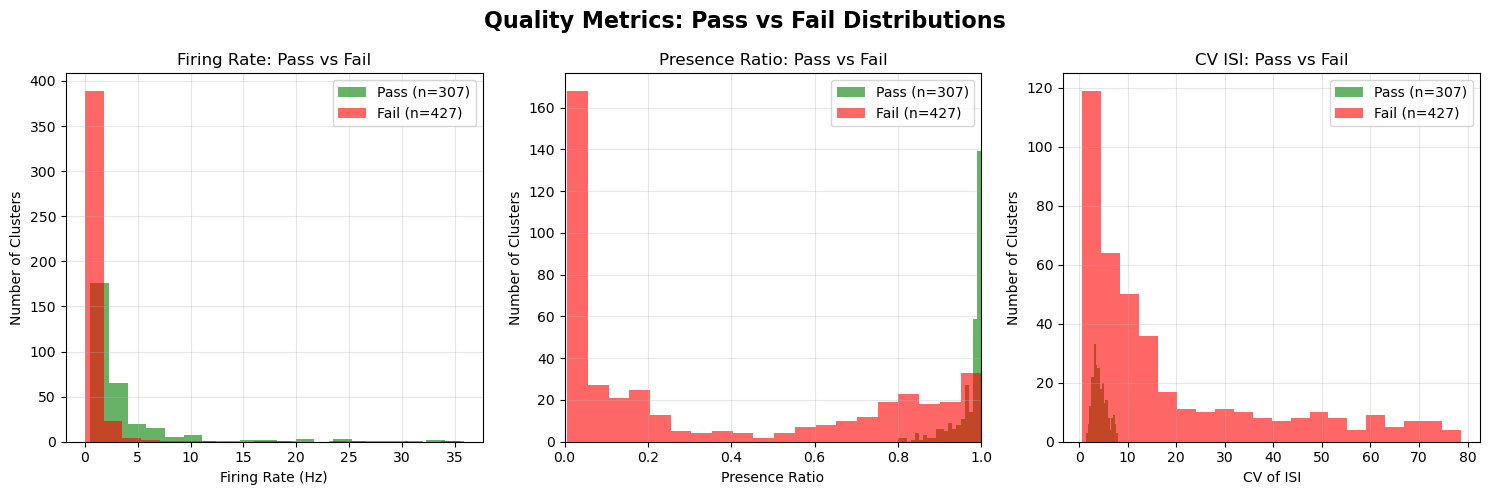

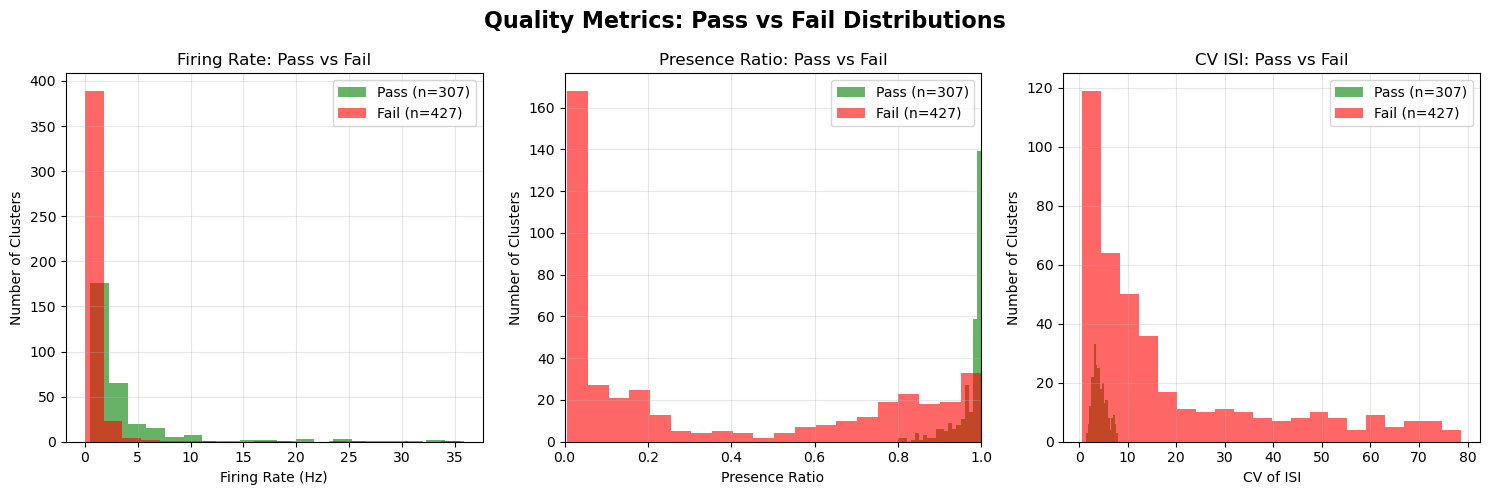

In [2]:
# Calculate firing pattern metrics and filter cells based on those metrics
import ephys.plot_ephys_qa_stats as pqa

metrics = ks_data.calculate_firing_pattern_metrics()
cells_filtered = ks_data.filter_cells_by_firing_patterns()
ks_data.print_firing_pattern_summary()
pqa.plot_pass_fail_histograms(metrics, cells_filtered)

In [4]:
# Load video tracking data
from video.tracking_import import VideoTrackingData
import video.plot_trajectory as pt

data_storage2 = DataStorageManager("rat631", "20251210", auto_load=True)
tracking_data = VideoTrackingData(data_storage2)
objects = tracking_data.get_object_names()
trajectory = tracking_data.get_object_trajectory(objects[0])
tracking_summary = tracking_data.export_summary()

Loading data paths for rat631/20251210
Data Availability Summary:
  - Ephys (Kilosort): ✓
  - DIO channels: [1, 2, 3, 4]
  - Video files: 49
  - Tracking files: 2
  - Behavioral event files: 0
  - Pulse log: ✓
Using tracking file from DataStorageManager: \\nearline\karpova\TervoLab\analysis\Tracking\manual_tracking\cohort7\RatCity_20251210_1359_40Hz\RatCity_20251210_1359_40Hz_mask_metrics.csv
Loading tracking data from: \\nearline\karpova\TervoLab\analysis\Tracking\manual_tracking\cohort7\RatCity_20251210_1359_40Hz\RatCity_20251210_1359_40Hz_mask_metrics.csv
Using tracking file from DataStorageManager: \\nearline\karpova\TervoLab\analysis\Tracking\manual_tracking\cohort7\RatCity_20251210_1359_40Hz\RatCity_20251210_1359_40Hz_mask_metrics.csv
Successfully loaded tracking data: 862048 rows, 13 columns
Parsing tracking data by objects...
Parsed object '613': 71842 rows, 11 columns
Parsed object '615': 71843 rows, 11 columns
Parsed object '616': 71804 rows, 11 columns
Parsed object '617': 7

Plotted path for rat631: 71844 points, 44519.6 pixels total distance
Plotted paths for 12 animals
Created occupancy-based Voronoi territorial diagram with 2732 seed points from 12 animals
Analyzing proximity interactions with threshold 100 pixels...
Found 35 significant interactions between animals

Proximity Network Analysis Results:
  Animals analyzed: 12
  Significant interactions: 35
  Network density: 0.530


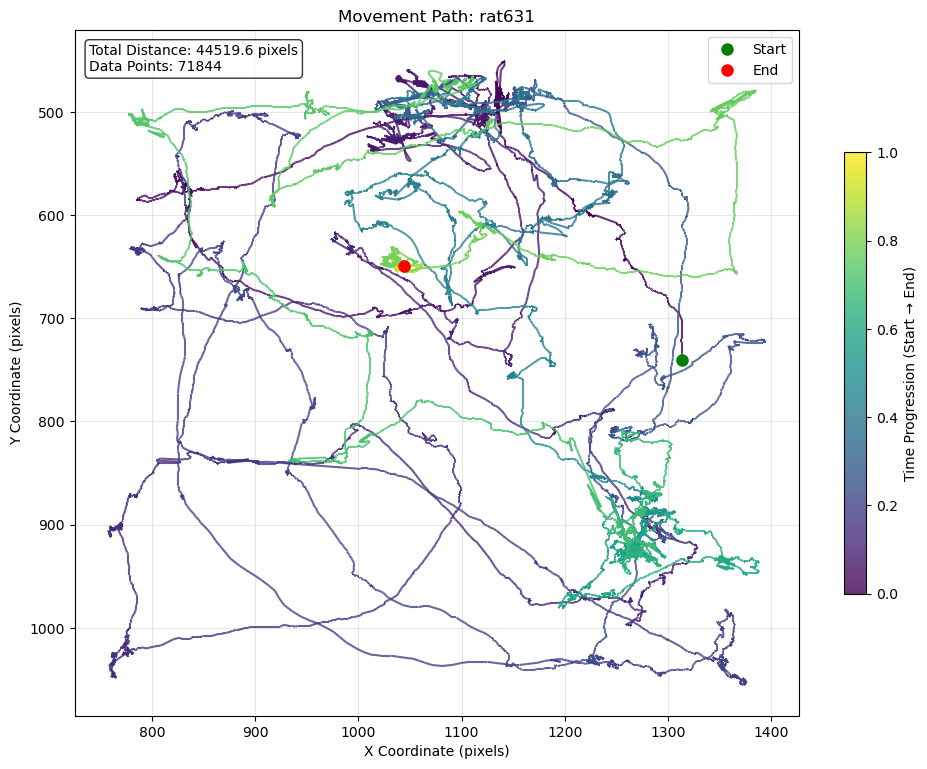

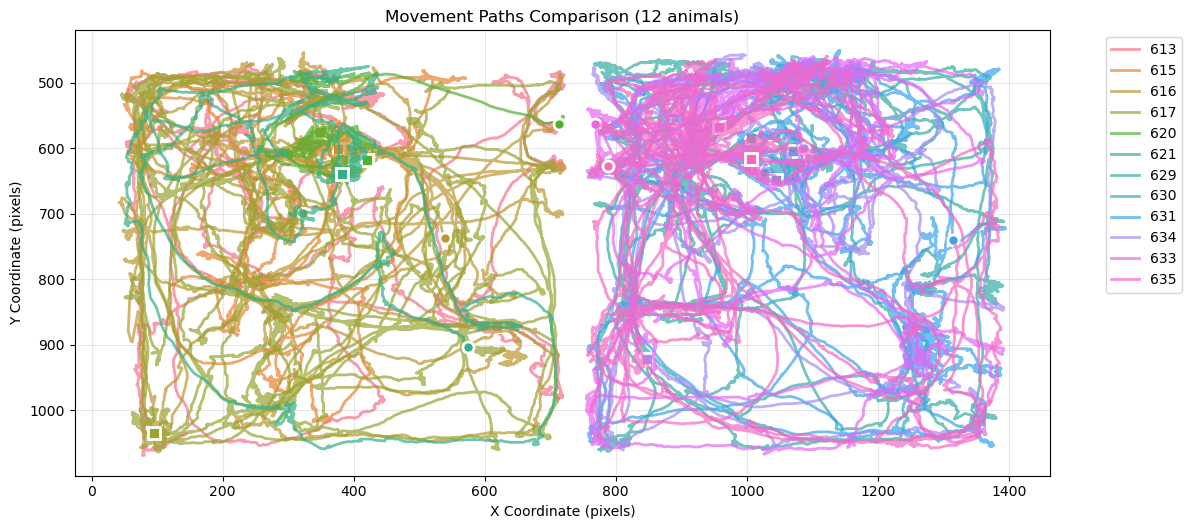

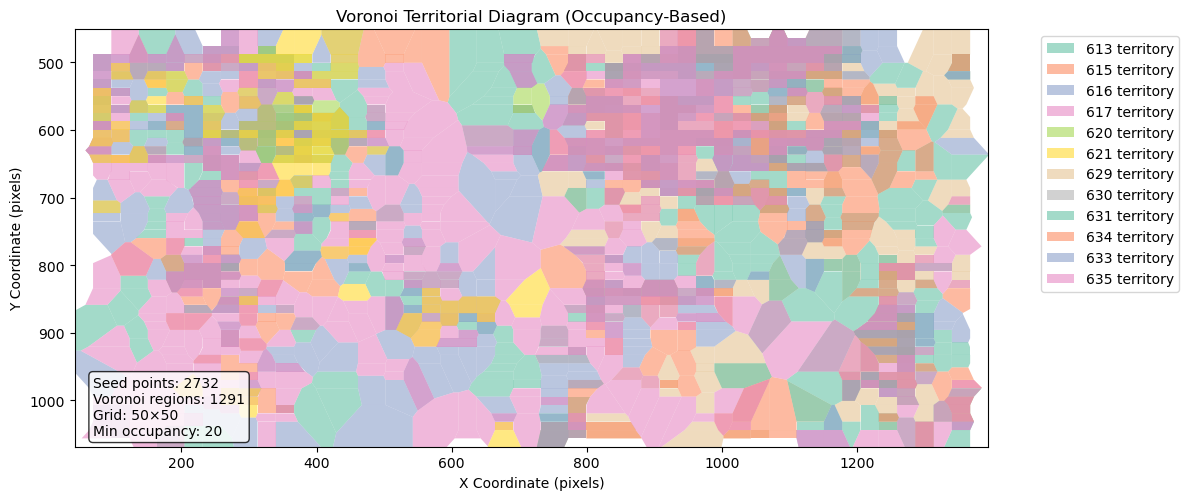

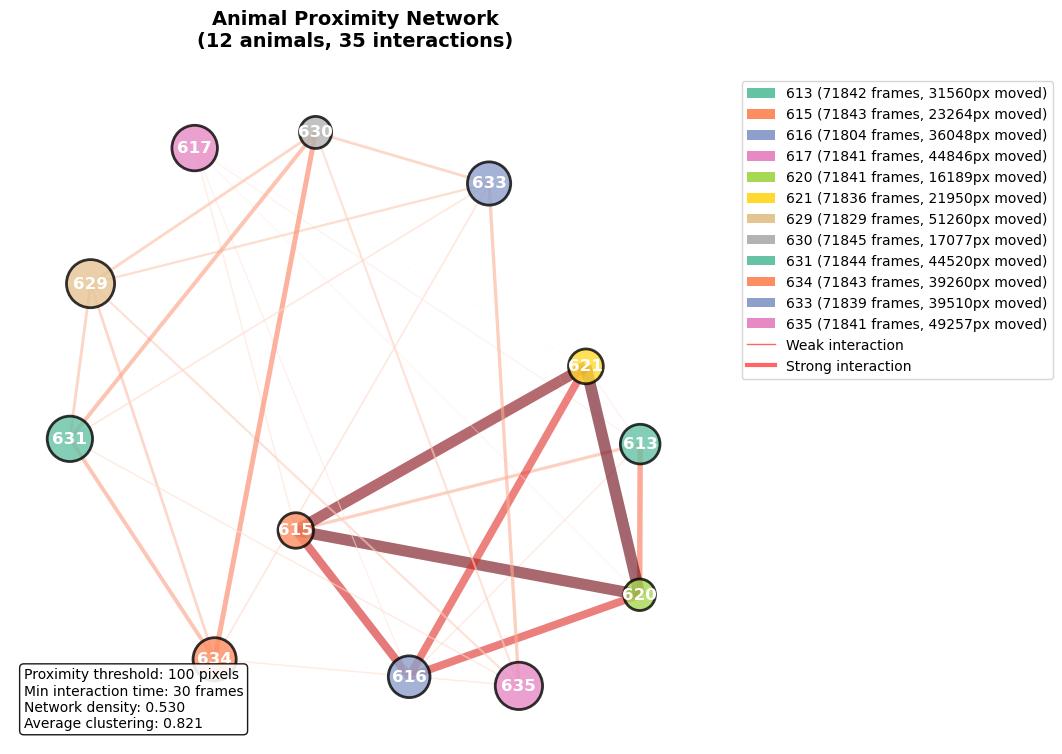

In [5]:
# Plotting examples for animal paths, territorial occupancy, Voronoi territories, and proximity networks
fig1 = pt.plot_animal_path(tracking_data.parsed_data['631'], 'rat631')
fig2 = pt.plot_multiple_paths(tracking_data.parsed_data)
# fig3 = pt.plot_territorial_occupancy(tracking_data.parsed_data)
fig4 = pt.plot_voronoi_territories(tracking_data.parsed_data)
fig5 = pt.plot_proximity_network(tracking_data.parsed_data)

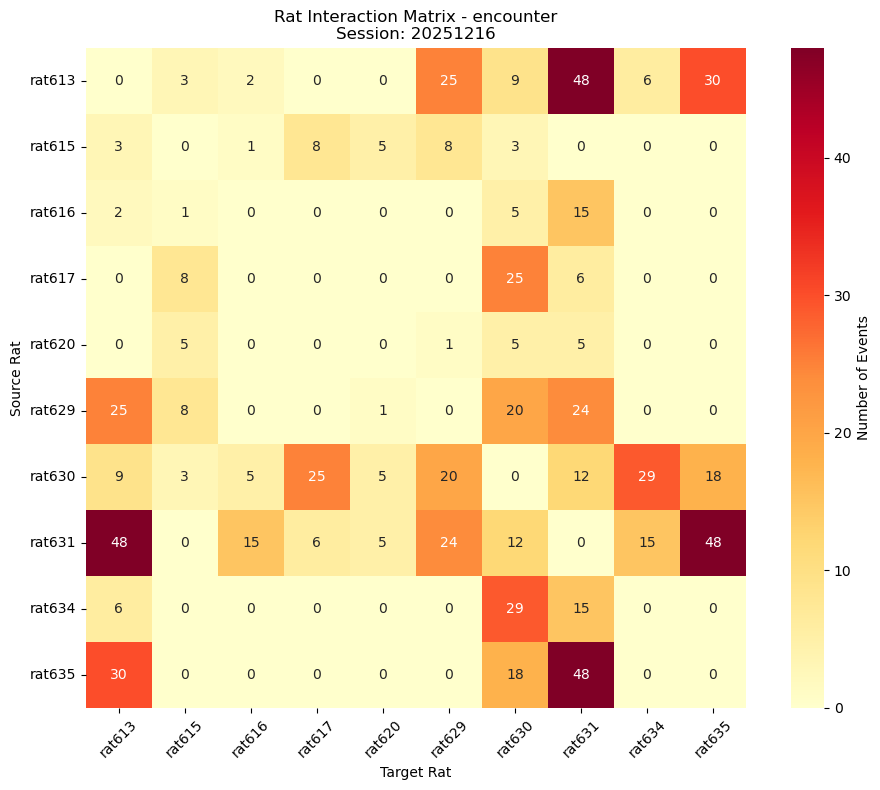

Found 233 events for rat rat631 (role: any)


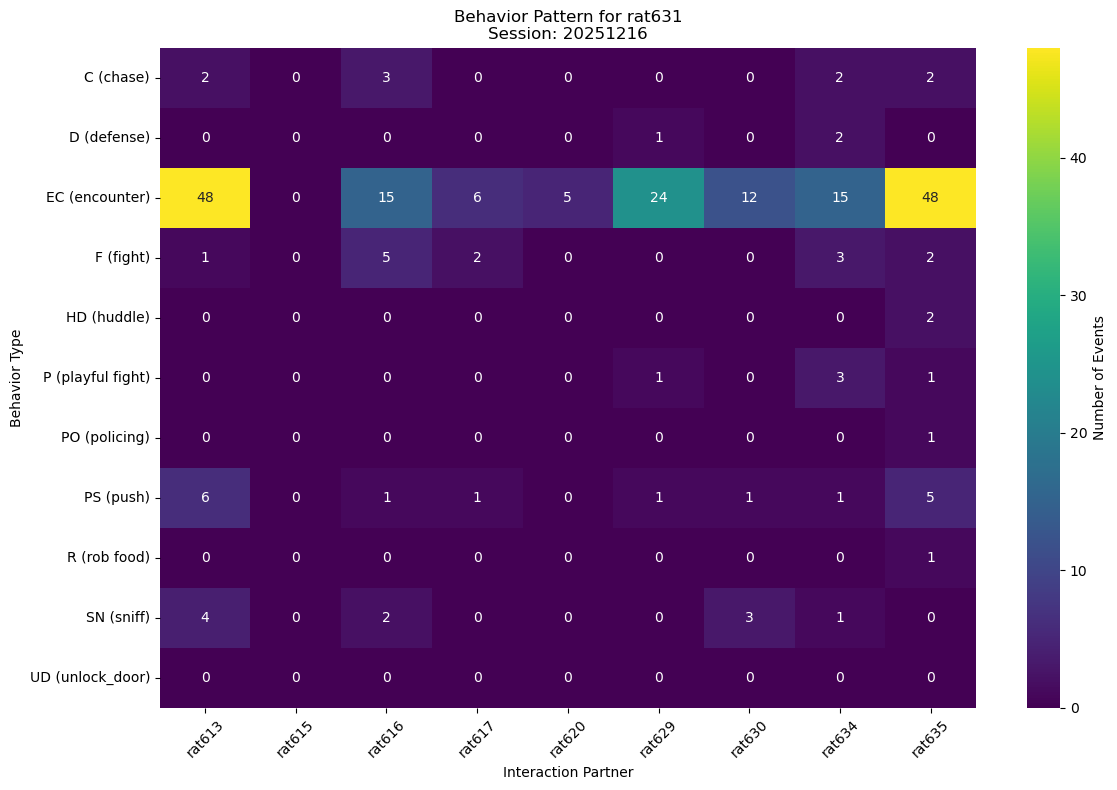

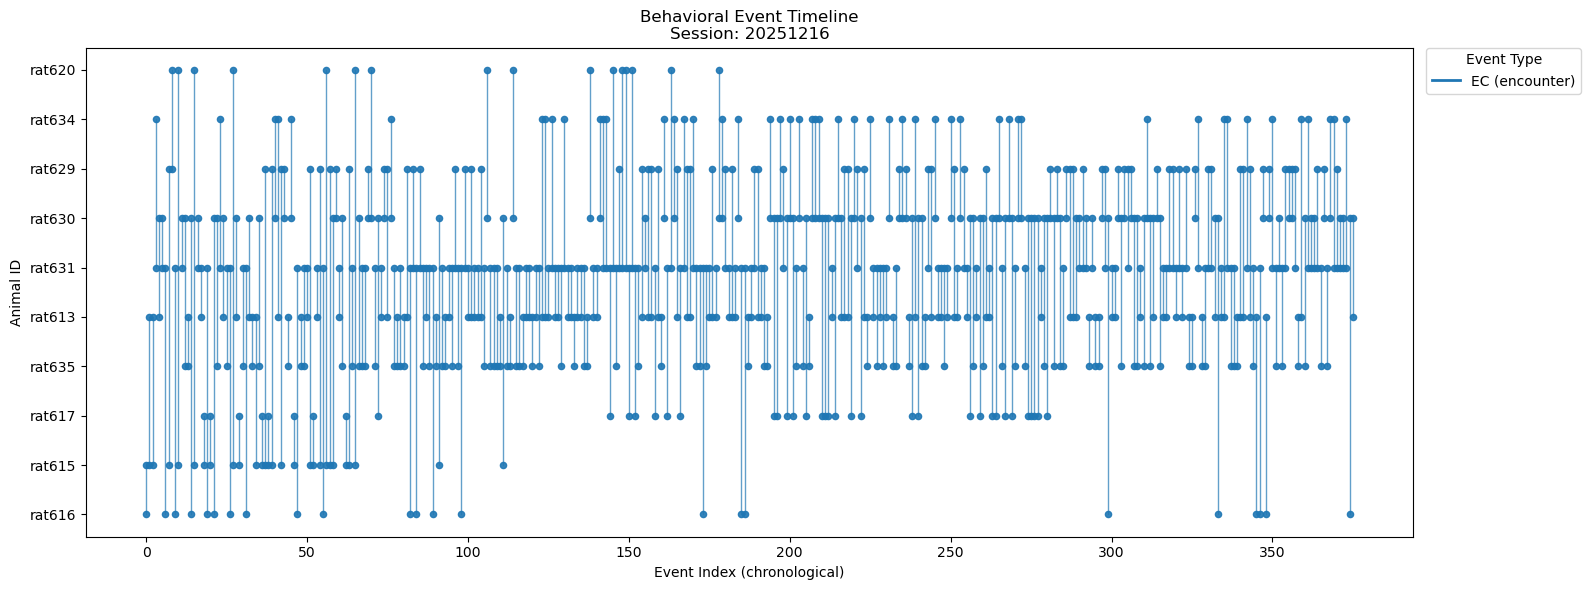

In [6]:
# Plotting examples for interaction heatmaps and behavior heatmaps
import video.behavioral_visualization as bv

bv.plot_rat_interaction_heatmap(behavior_data, event_type='EC')
bv.plot_rat_behavior_heatmap(behavior_data, '631')
bv.plot_behavioral_event_timeline(behavior_data, event_types=['EC'])

✓ Found 96 EC events with opponent labels
✓ Unique opponents: ['rat613' 'rat635']
✓ Found 96 EC events with opponent labels
✓ Unique opponents: ['rat613' 'rat635']
Found 96 behavioral events
Using 210 quality-filtered cells
Processing cell 1/210 (cluster 126)
Processing cell 51/210 (cluster 551)
Processing cell 101/210 (cluster 846)
Processing cell 151/210 (cluster 1043)
Processing cell 201/210 (cluster 1210)
Successfully decoded 210/210 cells
✓ Found 96 EC events with opponent labels
✓ Unique opponents: ['rat613' 'rat635']


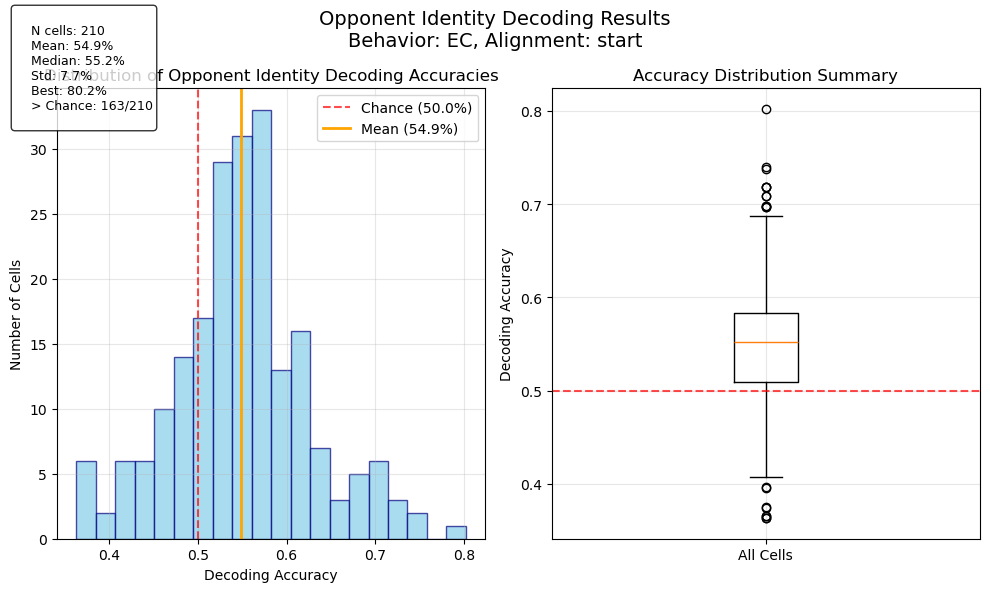

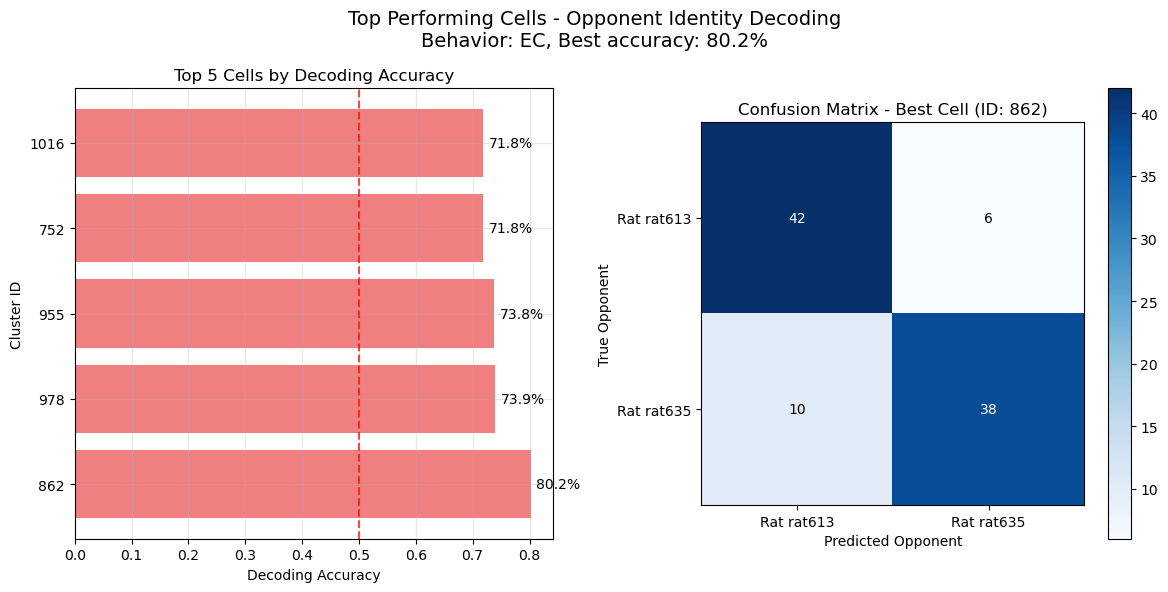

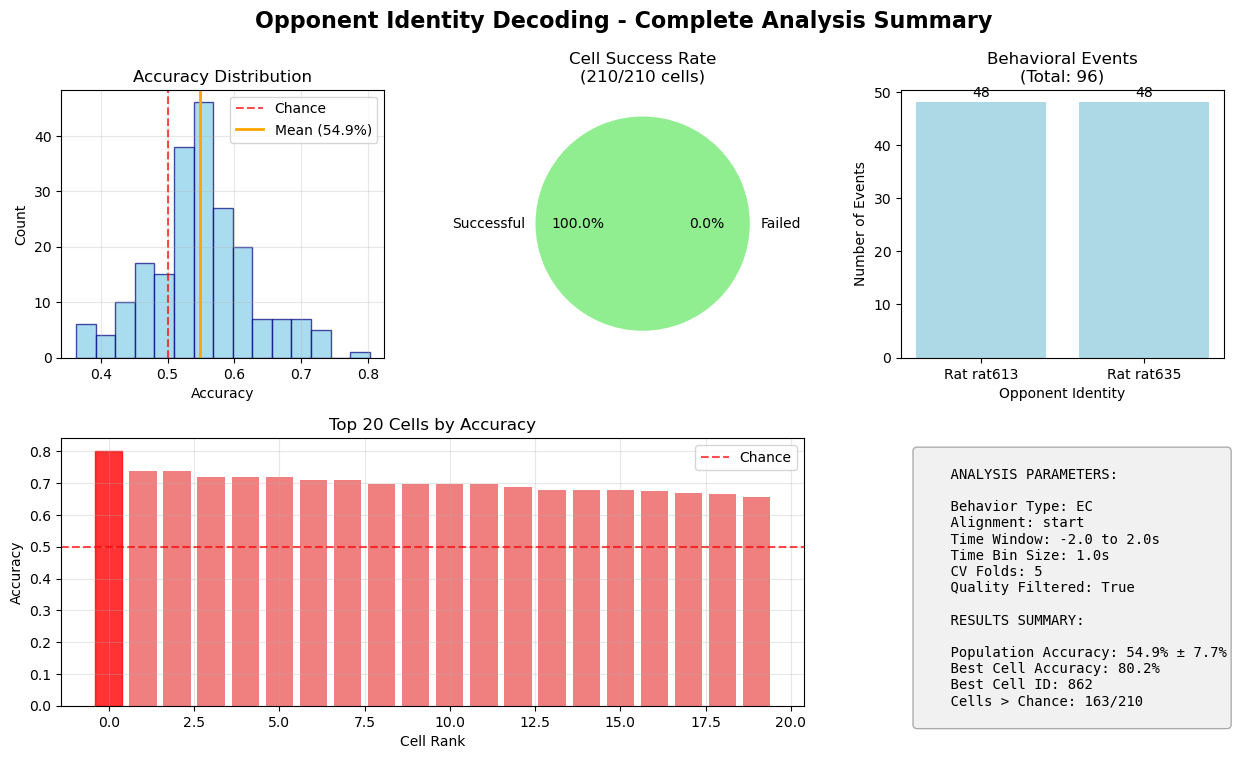

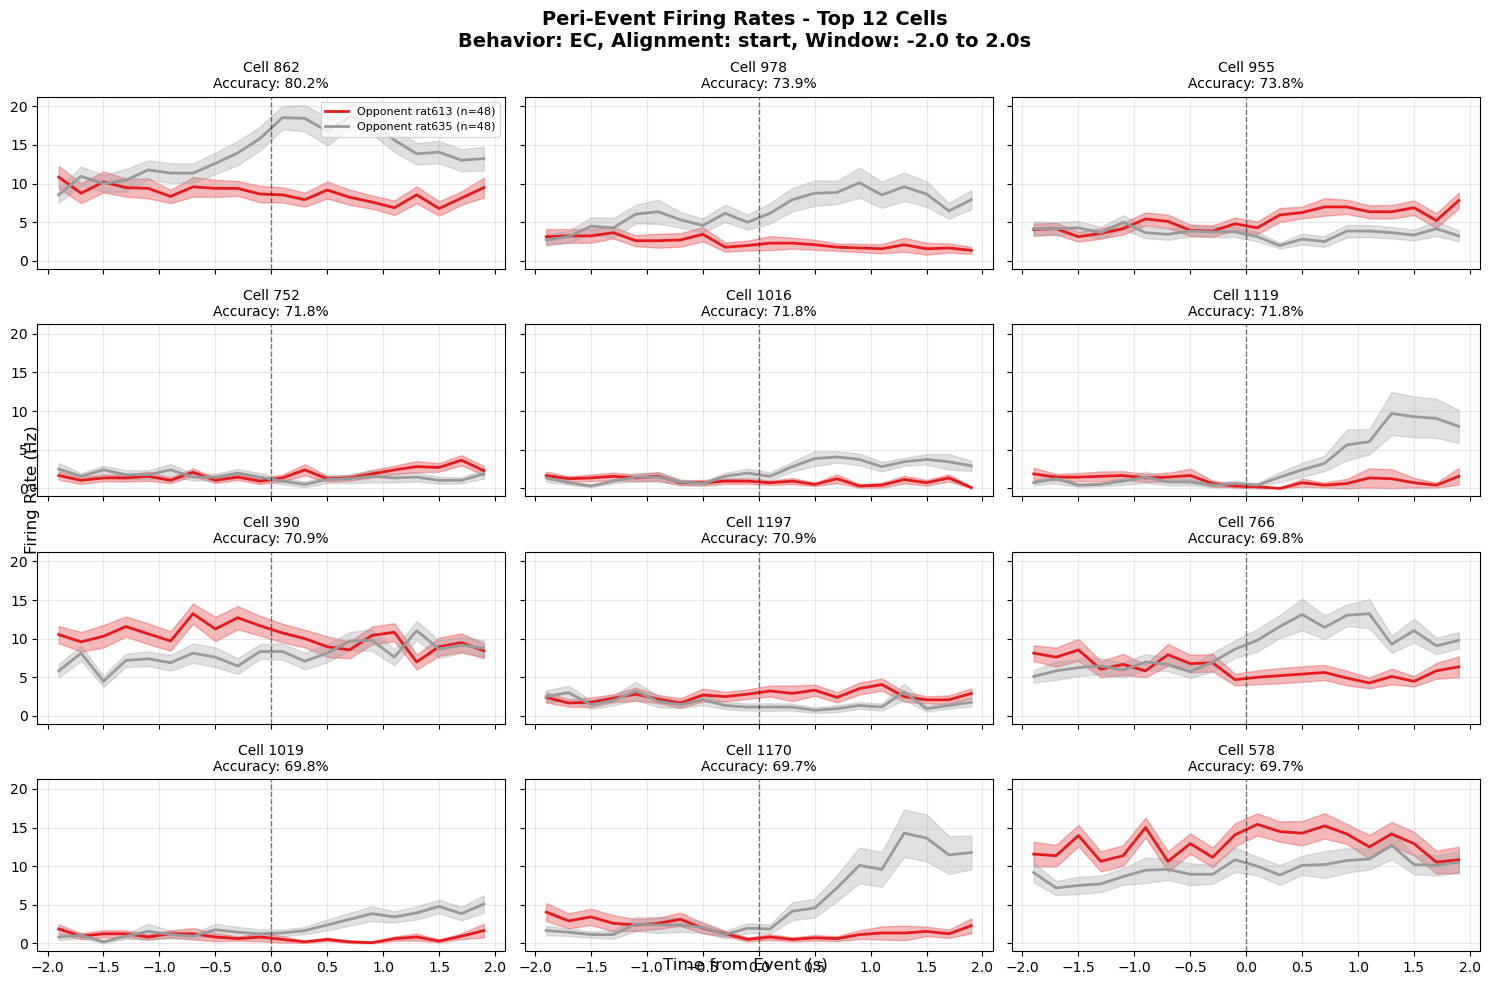

In [10]:
# Decode opponent identity for encounter events
import ephys.decode_opponent_identity as doi
import numpy as np
animal_id = "rat631"

# Test extracting opponent labels for fights with animal of interest
event_starts, event_ends, opponent_labels = behavior_data.extract_opponent_labels( 
    animal_of_interest=animal_id,
    behavior_type='EC',
    min_events_per_class=30
)

# Run decoding with a small subset for testing
test_results = doi.decode_opponent_identity_population(
    ks_data=ks_data,
    behavior_data=behavior_data,
    animal_of_interest=animal_id,
    behavior_type='EC',  # Encounter events
    use_quality_cells=True,
    alignment='start',
    time_window=(-2.0, 2.0),  # Smaller window for faster testing
    time_bin_size=1.0, # Larger bins for faster testing
    cv_folds=5,  # Fewer folds for faster testing
    min_events_per_class=30  # Lower threshold for testing
)
         
# Accuracy distribution plot
fig1 = doi.plot_decoding_accuracy_distribution(test_results, figsize=(10, 6))

# Best cells plot
fig2 = doi.plot_best_cells_decoding(test_results, n_top_cells=5, figsize=(12, 6))
    
# Summary plot
fig3 = doi.plot_decoding_summary(test_results, figsize=(15, 8))

# Plot firing rates of top cells around events
fig4 = doi.plot_top_cells_firing_rates(
            ks_data=ks_data,
            behavior_data=behavior_data, 
            test_results=test_results,
            time_window=(-2.0, 2.0),  # Same as analysis window
            time_bin_size=0.2,       # Finer resolution for PETH
            n_top_cells=12,            # Show top 6 cells
            figsize=(15, 10)
        )

✓ Found 173 EC events with opponent labels
✓ Unique opponents: ['rat613' 'rat616' 'rat617' 'rat620' 'rat629' 'rat630' 'rat634' 'rat635']


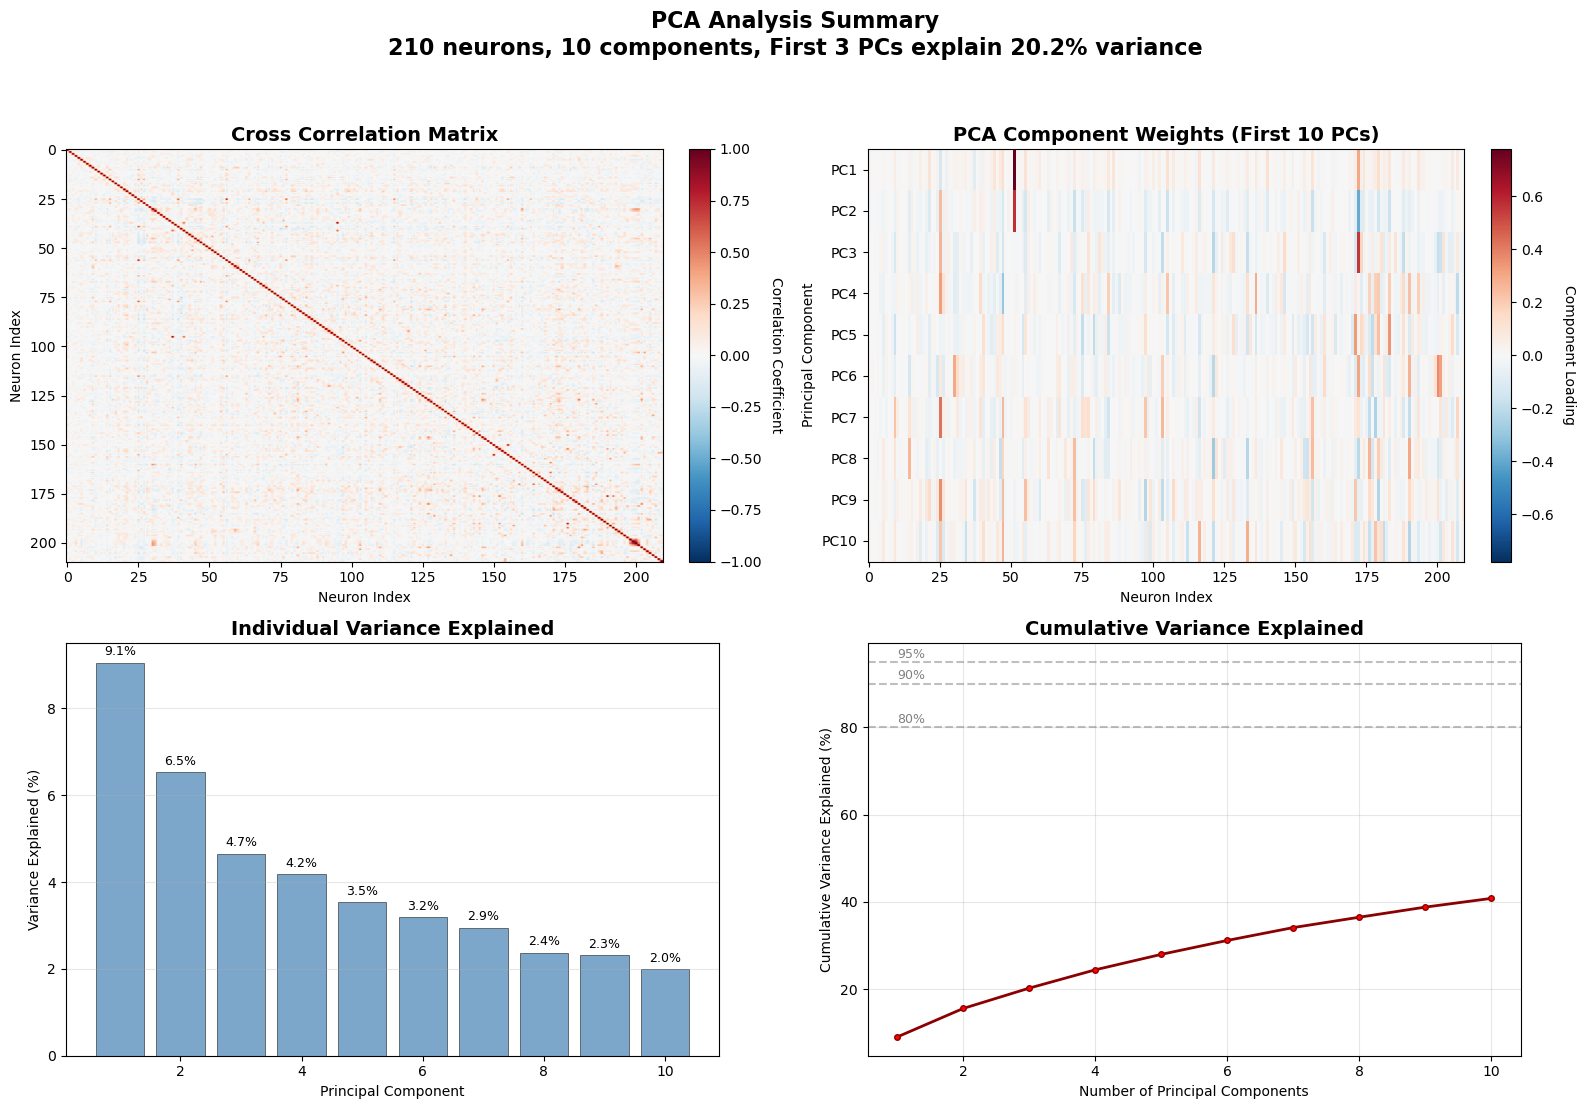

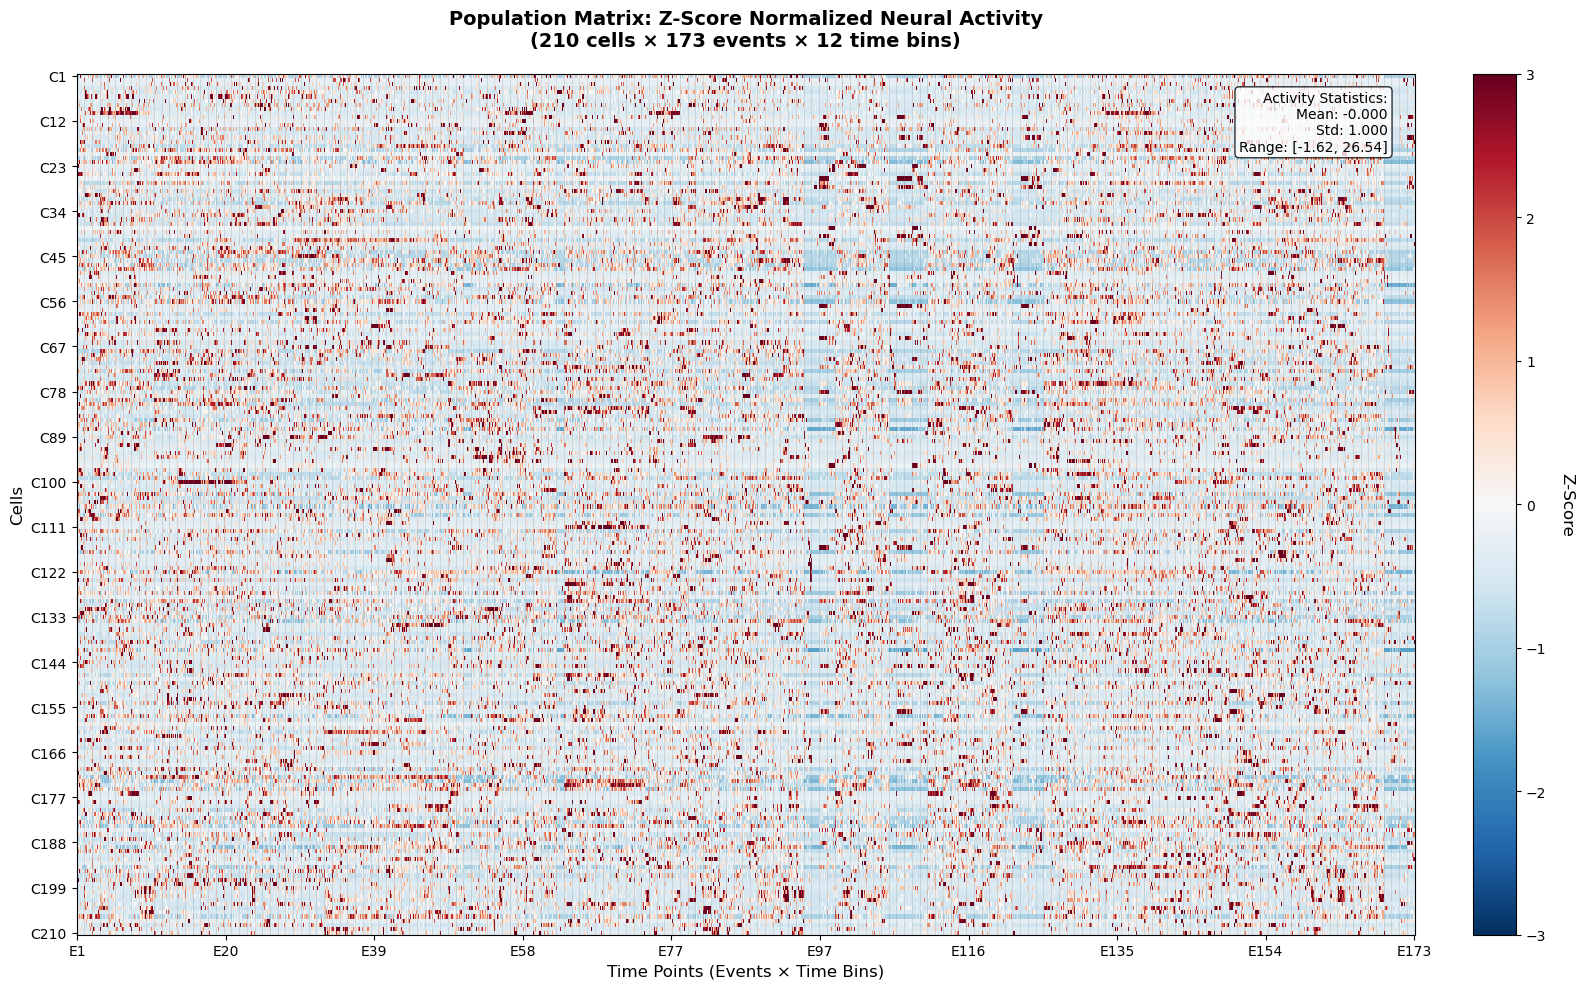

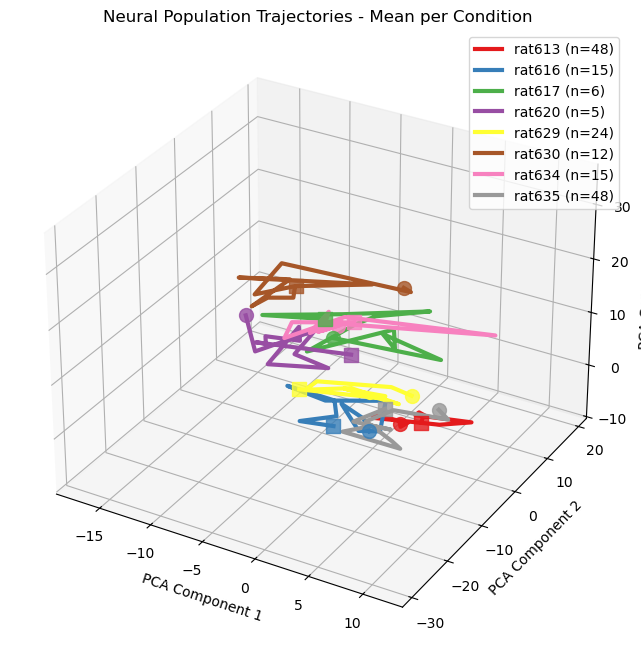

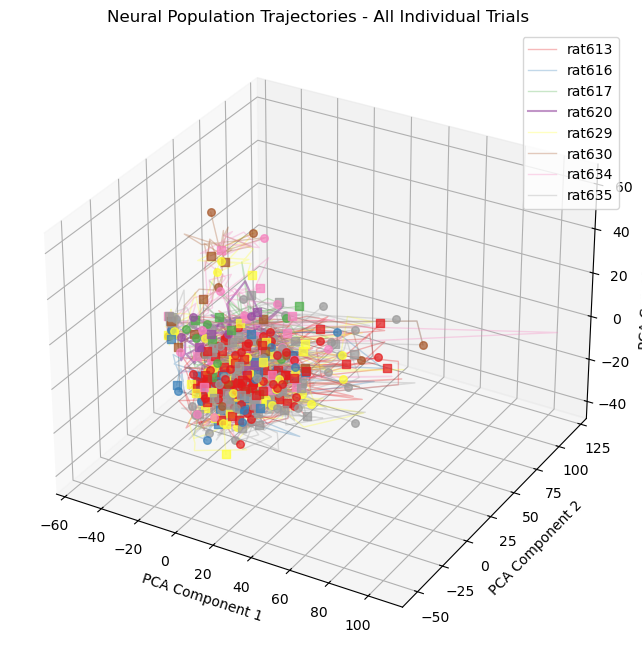

In [8]:
# Test population geometry analysis and plotting
import importlib
import ephys.population_geometry as pg
importlib.reload(pg)  # Reload the population geometry module to ensure we have the latest version
analyzer = pg.PopulationGeometryAnalyzer(ks_data, behavior_data)
event_starts, event_ends, opponent_labels = behavior_data.extract_opponent_labels(
    animal_of_interest="rat631",
    behavior_type='EC',
    min_events_per_class=5
)

if len(event_starts) > 0:
    pop_matrix = analyzer.construct_population_matrix(
        event_starts=event_starts,
        event_ends=event_ends,
        event_labels=opponent_labels,
        time_window=(-2.0, 4.0),
        time_bin_size=0.5,
        alignment='start',
        normalize_method='none'  # No normalization for testing purposes
    )
reduced_data = analyzer.apply_dimensionality_reduction(pop_matrix, method='PCA', n_components=10)
fig_pca_summary = analyzer.plot_pca_summary(
        reduced_data=reduced_data, 
        pop_data=pop_matrix['population_data'],  # Pass original population data
        figsize=(16, 12)
    )

fig_normalized = analyzer.plot_normalized_population_matrix(
    pop_data=pop_matrix['population_data'],
    figsize=(16, 10)
)
fig_mean = analyzer.plot_population_dynamics(reduced_data, show_individual=False)
fig_individual = analyzer.plot_population_dynamics(reduced_data, show_individual=True)